In [30]:
import os
import numpy as np
import sys
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


In [31]:
# Get the directory of the script
script_dir = os.getcwd()

# Get the parent directory of the script
parent_dir = os.path.dirname(os.path.dirname(script_dir))

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from core.autoencoders import AE, train_ae
from core.dataset import TIFFDataset
from utils.feature_analysis import UMAP_train, patch_csv_to_AE_latent, patch_2_normed_tensor,data_to_latents, kmeans_latents,latent_to_umap,UMAP_train,DBSCAN_cluster,kmeans_cluster,dataloader_model_latents,add_features_to_latent
from utils.plotting_utils import umap_2Dplot, cluster_2Dplot


In [32]:
# load old sheets

root_dir = '/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/results/pax_wholecell_correctloader_ch1_ps32_latdim_8_20251203_2323'
latent_array = joblib.load(os.path.join(root_dir, 'latent_array_plus6_ctrl_y.pkl'))
patch_label_df = pd.read_csv(os.path.join(root_dir, 'patch_label_df_lat9umap2.csv'))
# df_clean = pd.read_csv(os.path.join(root_dir, 'label_20260223_combined_lat8.csv'))

df_clean = pd.read_csv(os.path.join(root_dir, 'label_20260223_combined_lat8_equalweight.csv'))


In [48]:
df_clean.columns

Index(['Unnamed: 0.1', 'unique_ID', 'Unnamed: 0', 'UMAP_d0', 'UMAP_d1',
       'dist_cell_edge', 'front_flag', 'Position', 'classification',
       'group_ID', 'group', 'actin_patch_image', 'annotation_id', 'annotator',
       'bbox_x1', 'bbox_x2', 'bbox_y1', 'bbox_y2', 'created_at',
       'crop_img_filename', 'csv_row_index', 'czi_filename',
       'fa_class_pred_id', 'fa_class_pred_label', 'filename_id', 'id', 'image',
       'joint_pred_id', 'lead_time', 'original_x_c', 'original_y_c',
       'patch_center_x', 'patch_center_y', 'paxillin_patch_image',
       'position_pred_id', 'position_pred_label', 'project_id', 'rand_angle',
       'rand_tx', 'rand_ty', 'reference_image', 'updated_at',
       'vinppax_patch_image', 'zyxin_patch_image', 'sample_weight', 'lat_d0',
       'lat_d1', 'lat_d2', 'lat_d3', 'lat_d4', 'lat_d5', 'lat_d6', 'lat_d7'],
      dtype='object')

In [33]:
# CODEX CHANGED: split from df_clean generated above
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df_clean,
    test_size=0.2,
    random_state=0,
    shuffle=True,
    # optionally stratify:
    stratify=df_clean["classification"]
)


In [49]:
train_df

,Unnamed: 0.1,unique_ID,Unnamed: 0,UMAP_d0,UMAP_d1,dist_cell_edge,front_flag,Position,classification,group_ID,...,zyxin_patch_image,sample_weight,lat_d0,lat_d1,lat_d2,lat_d3,lat_d4,lat_d5,lat_d6,lat_d7
4,354,control-f0001x0368y0528ps32.tif,3.0,7.103175,-0.058455,5.0,0.0,Cell Periphery/other,No adhesion,0.0,...,NaN,1.0,-3.296754,-2.140397,1.562945,5.854156,4.291277,12.685116,-13.712293,-2.580447
244,6396,control-f0024x0496y0496ps32.tif,148.0,-0.129978,-0.424156,97.0,255.0,Lamella,focal adhesion,0.0,...,NaN,1.0,-0.238541,0.172571,-0.016205,1.056109,2.643858,4.267868,-2.929420,-1.963369
94,3455,control-f0012x0816y0336ps32.tif,NaN,NaN,NaN,NaN,NaN,Lamella,focal adhesion,0.0,...,s3://cls-label-bucket/2026_02_03_VinPaxData_Pa...,1.0,1.534862,2.795621,5.280447,-1.999438,-3.709946,0.878638,-7.501369,-4.338041
1079,20501,ycomp-f0030x0144y0528ps32.tif,NaN,NaN,NaN,NaN,NaN,Cell Protruding Edge,Nascent Adhesion,1.0,...,s3://cls-label-bucket/2026_02_03_VinPaxData_Pa...,1.0,-2.966984,-0.556985,-6.916507,2.870614,1.528426,7.237561,-10.183977,2.626919
1093,20750,ycomp-f0030x1008y0240ps32.tif,NaN,NaN,NaN,NaN,NaN,Cell Body,No adhesion,1.0,...,s3://cls-label-bucket/2026_02_03_VinPaxData_Pa...,1.0,0.486862,4.115192,0.847625,0.944131,-3.352246,2.888213,0.128184,-3.681200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1035,19923,ycomp-f0028x0656y0848ps32.tif,NaN,NaN,NaN,NaN,NaN,Cell Body,No adhesion,1.0,...,s3://cls-label-bucket/2026_02_03_VinPaxData_Pa...,1.0,-0.215688,4.915976,-0.398820,3.162133,2.364949,3.577688,-6.173177,-0.785343
550,14874,ycomp-f0007x0912y0752ps32.tif,NaN,NaN,NaN,NaN,NaN,Cell Protruding Edge,focal complex,1.0,...,s3://cls-label-bucket/2026_02_03_VinPaxData_Pa...,1.0,-1.419630,-4.943074,-17.361155,-6.976108,-13.793433,23.406977,-27.823166,-9.800849
953,18990,ycomp-f0024x0752y0880ps32.tif,NaN,NaN,NaN,NaN,NaN,Lamella,Nascent Adhesion,1.0,...,s3://cls-label-bucket/2026_02_03_VinPaxData_Pa...,1.0,1.316837,-1.238823,-3.020226,2.966003,2.481794,7.148337,-10.007609,0.460722
441,14156,ycomp-f0004x0752y0496ps32.tif,236.0,4.877129,-0.822216,11.0,255.0,Cell Protruding Edge,focal complex,1.0,...,NaN,1.0,-3.257911,-3.048325,3.205013,10.249321,-7.424480,8.713572,-7.999679,-4.162314


In [34]:
classification_label_order = [
    "Nascent Adhesion",
    "focal complex",
    "focal adhesion",
    "fibrillar adhesion",
    "No adhesion",
    "Uncertain",
]

position_label_order = [
    "Cell Protruding Edge",
    "Cell Periphery/other",
    "Lamella",
    "Cell Body",
    "No Category/uncertain",
]

fa_id_to_label = {
     i :label
    for i, label in enumerate(classification_label_order)
}
position_id_to_label = {
    i: label
    for i, label in enumerate(position_label_order)
}

fa_label_to_id = {
    label: i
    for i, label in enumerate(classification_label_order)
}

position_label_to_id = {
    label: i
    for i, label in enumerate(position_label_order)
}

In [68]:
from sklearn.ensemble import HistGradientBoostingClassifier

feature_cols = [f"lat_d{i}" for i in range(8)]  # change to your latent column names
target_col = "classification"                     # change

X_train = train_df[feature_cols].values
y_train = train_df[target_col].map(fa_label_to_id)
y_train_Position = train_df["Position"].map(position_label_to_id)
w_train = train_df["sample_weight"].values

X_val = val_df[feature_cols].values
y_val = val_df[target_col].map(fa_label_to_id)
y_val_Position = val_df["Position"].map(position_label_to_id)

w_val = val_df["sample_weight"].values



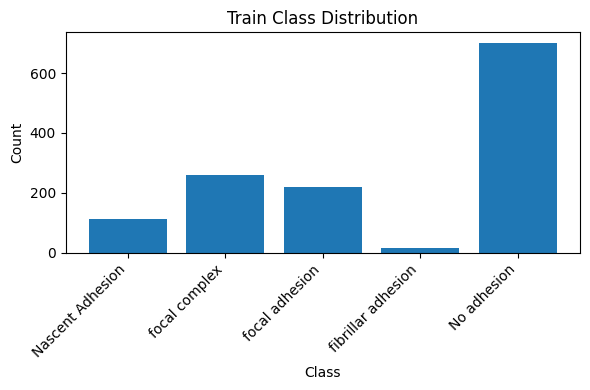

In [64]:

class_names = classification_label_order[:-1]
n_classes = len(class_names)

plt.figure(figsize=(6, 4))

plt.hist(
    df_clean[target_col].map(fa_label_to_id),
    bins=np.arange(n_classes + 1) - 0.5,
    rwidth=0.8
)

plt.xticks(
    np.arange(n_classes),
    class_names,
    rotation=45,
    ha="right"
)

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Train Class Distribution")

plt.tight_layout()
plt.show()


In [75]:
len(class_names)

5

In [78]:
def plot_cm(y_val, y_pred,class_names,method_str ):
    cm = confusion_matrix(y_val, y_pred)
    acc = accuracy_score(y_val, y_pred)

    class_names = class_names
    fig, ax = plt.subplots(figsize=(6, 6))

    im = ax.imshow(np.sqrt(cm[:len(class_names),:len(class_names)]), cmap="Blues",vmax=np.sqrt(cm).max()*(0.8))

    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(f"{method_str} CM on Val set, ACC={acc:.2f}")
    
    # annotate cells
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, cm[i, j],
                    ha="center", va="center")

    plt.tight_layout()
    plt.show()


In [38]:
!pip install xgboost

In [39]:
import xgboost as xgb
from xgboost import XGBClassifier

# K = number of classes (optional if y is 0..K-1; XGBoost often infers it)
# K = len(np.unique(y_train))

clf = XGBClassifier(
    n_estimators=5000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    tree_method="hist",      # fast CPU histogram method
    objective="multi:softprob",
    eval_metric="mlogloss",  # or "merror"
    n_jobs=-1,
    random_state=42,
    # num_class=K,          # uncomment if needed
    early_stopping_rounds=100,
)

clf.fit(
    X_train, y_train,
    sample_weight=w_train,
    eval_set=[(X_val, y_val)],
    sample_weight_eval_set=[w_val],
    verbose=False,
)

from sklearn.metrics import roc_auc_score, accuracy_score

proba = clf.predict_proba(X_val)  # (n_samples, n_classes)
xgb_val_pred  = clf.predict(X_val)

auc_ovr = roc_auc_score(y_val, proba, multi_class="ovr", average="macro")
acc = accuracy_score(y_val, xgb_val_pred)

print("AUC OVR macro:", auc_ovr)
print("Acc:", acc)

AUC OVR macro: 0.667508688557019
Acc: 0.6030534351145038


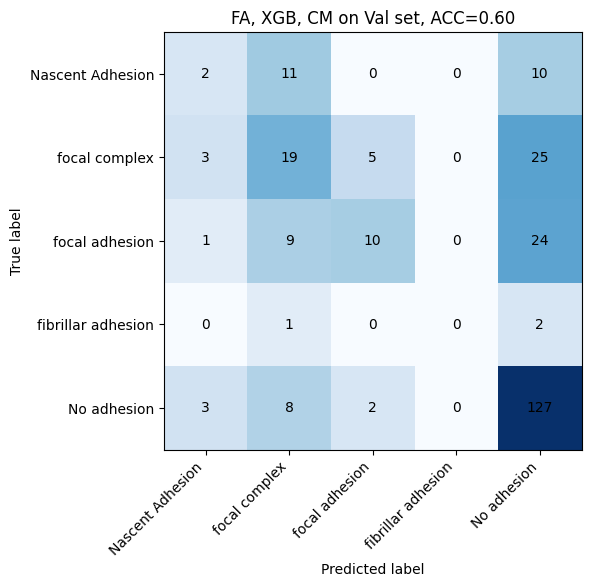

In [40]:
plot_cm(y_val, xgb_val_pred,classification_label_order[:-1], "FA, XGB," )

In [41]:
!pip install lightgbm

In [70]:
y_train_Position

4       1
244     2
94      2
1079    0
1093    3
       ..
1035    3
550     0
953     2
441     0
1305    1
Name: Position, Length: 1048, dtype: int64

In [82]:
all2_pred_df = predict_all_samples(all_pred_df, feature_cols, lightgbm_clf_Position, 'Position_pred')

In [87]:
all2_pred_df['group_labels']

0        0
1        0
2        0
3        0
4        0
        ..
23651    1
23652    1
23653    1
23654    1
23655    1
Name: group_labels, Length: 23656, dtype: int64

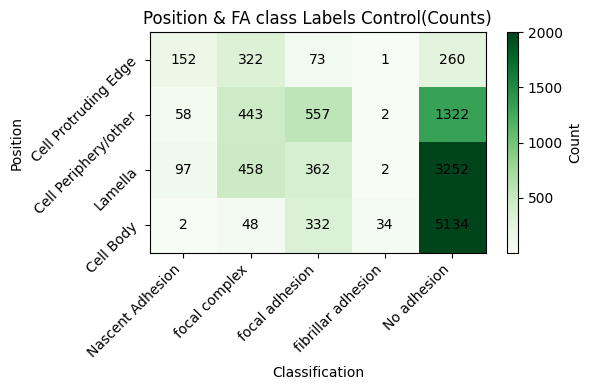

In [91]:
df =all2_pred_df
mask = df["group_labels"] ==0

y_position_all_pred = all2_pred_df["Position_pred"]
y_FA_class_all_pred = all2_pred_df["FA_pred"]

ct_pred = pd.crosstab(
    y_position_all_pred[mask], y_FA_class_all_pred[mask])

fig, ax = plt.subplots(figsize=(6, 4))

im = ax.imshow(ct_pred.values[0:4, 0:5], cmap="Greens", aspect="auto",vmax=2000)


plt.xticks(
    np.arange(5),
    classification_label_order[:-1],
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(4),
    position_label_order[:-1],
    rotation=45,
    ha="right")


ax.set_xlabel("Classification")
ax.set_ylabel("Position")
ax.set_title("Position & FA class Labels Control(Counts)")

# annotate cells
for i in range(4):
    for j in range(5):
        ax.text(j, i, ct_pred.values[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()

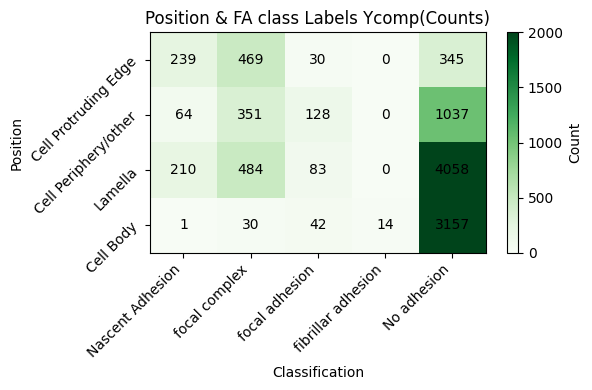

In [92]:
df =all2_pred_df
mask = df["group_labels"] ==1

y_position_all_pred = all2_pred_df["Position_pred"]
y_FA_class_all_pred = all2_pred_df["FA_pred"]

ct_pred = pd.crosstab(
    y_position_all_pred[mask], y_FA_class_all_pred[mask])

fig, ax = plt.subplots(figsize=(6, 4))

im = ax.imshow(ct_pred.values[0:4, 0:5], cmap="Greens", aspect="auto",vmax=2000)


plt.xticks(
    np.arange(5),
    classification_label_order[:-1],
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(4),
    position_label_order[:-1],
    rotation=45,
    ha="right")


ax.set_xlabel("Classification")
ax.set_ylabel("Position")
ax.set_title("Position & FA class Labels Ycomp(Counts)")

# annotate cells
for i in range(4):
    for j in range(5):
        ax.text(j, i, ct_pred.values[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()

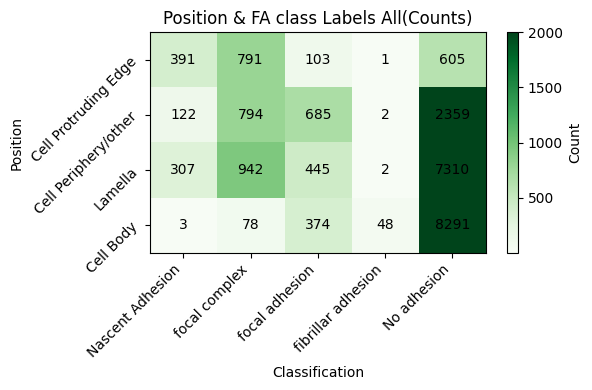

In [93]:
df =all2_pred_df
mask = df["group_labels"] >-1

y_position_all_pred = all2_pred_df["Position_pred"]
y_FA_class_all_pred = all2_pred_df["FA_pred"]

ct_pred = pd.crosstab(
    y_position_all_pred[mask], y_FA_class_all_pred[mask])

fig, ax = plt.subplots(figsize=(6, 4))

im = ax.imshow(ct_pred.values[0:4, 0:5], cmap="Greens", aspect="auto",vmax=2000)


plt.xticks(
    np.arange(5),
    classification_label_order[:-1],
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(4),
    position_label_order[:-1],
    rotation=45,
    ha="right")


ax.set_xlabel("Classification")
ax.set_ylabel("Position")
ax.set_title("Position & FA class Labels All(Counts)")

# annotate cells
for i in range(4):
    for j in range(5):
        ax.text(j, i, ct_pred.values[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()

In [ ]:
 Position_pred

,Unnamed: 0.1,Unnamed: 0,ctrl_y_str,crop_img_filename,group_labels,UMAP_d0,UMAP_d1,DBSCAN_labels,kmeans_labels,vinculin_intensity,...,group,unique_ID,FA_pred,pred_max_proba,proba_class0,proba_class1,proba_class2,proba_class3,proba_class4,Position_pred
0,0,0,ctrl,f0000x0080y0816ps32.tif,0,6.533898,2.949632,0,0,3470.368164,...,control,control-f0000x0080y0816ps32.tif,4,0.896289,0.059471,0.896289,0.023998,0.019985,0.000258,1
1,1,1,ctrl,f0000x0112y0784ps32.tif,0,0.613508,-1.430238,0,0,2753.338867,...,control,control-f0000x0112y0784ps32.tif,4,0.394790,0.144722,0.380332,0.394790,0.079601,0.000555,2
2,2,2,ctrl,f0000x0144y0784ps32.tif,0,4.134788,1.867131,0,0,4177.766602,...,control,control-f0000x0144y0784ps32.tif,1,0.464259,0.141212,0.464259,0.205595,0.188408,0.000526,1
3,3,3,ctrl,f0000x0176y0784ps32.tif,0,6.328398,2.741769,0,0,3782.319336,...,control,control-f0000x0176y0784ps32.tif,2,0.628338,0.230913,0.628338,0.103374,0.036900,0.000476,1
4,4,4,ctrl,f0000x0240y0752ps32.tif,0,5.109221,1.633341,0,0,3487.683594,...,control,control-f0000x0240y0752ps32.tif,2,0.454039,0.454039,0.426307,0.086620,0.032659,0.000375,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23651,23651,23651,y,f0040x0912y0624ps32.tif,1,6.696744,0.453905,0,0,4753.446289,...,ycomp,ycomp-f0040x0912y0624ps32.tif,4,0.460586,0.460586,0.178614,0.304407,0.055677,0.000716,0
23652,23652,23652,y,f0040x0912y0656ps32.tif,1,5.160360,1.301750,0,0,8459.265625,...,ycomp,ycomp-f0040x0912y0656ps32.tif,2,0.538426,0.244252,0.538426,0.184413,0.032536,0.000373,1
23653,23653,23653,y,f0040x0912y0688ps32.tif,1,3.375209,-0.521952,0,0,7675.988281,...,ycomp,ycomp-f0040x0912y0688ps32.tif,4,0.779714,0.071405,0.093964,0.779714,0.054489,0.000428,2
23654,23654,23654,y,f0040x0912y0720ps32.tif,1,5.753994,-0.231215,0,0,5432.383789,...,ycomp,ycomp-f0040x0912y0720ps32.tif,1,0.386340,0.158494,0.386340,0.356537,0.098040,0.000589,1


In [71]:
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score

lightgbm_clf_Position = LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=31,
    n_jobs=-1,
    objective="multiclass",
)

lightgbm_clf_Position.fit(
    X_train, y_train_Position,
    sample_weight=w_train,
    eval_set=[(X_val, y_val_Position)],    
    eval_metric="multi_logloss",
    callbacks=[lgb.early_stopping(100)]
)
pred_proba_Position = lightgbm_clf_Position.predict_proba(X_val)[:, 1]
pred_label_Position = lightgbm_clf_Position.predict(X_val)

lightgbm_val_pred_Position = lightgbm_clf_Position.predict(X_val)
print("Acc:", accuracy_score(y_val_Position, lightgbm_val_pred_Position))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000096 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 1048, number of used features: 8
[LightGBM] [Info] Start training from score -1.836645
[LightGBM] [Info] Start training from score -1.143498
[LightGBM] [Info] Start training from score -1.425210
[LightGBM] [Info] Start training from score -1.277885
[LightGBM] [Info] Start training from score -5.856027
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

/home/ldin/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ldin/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ldin/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import lightgbm as lgb
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score

lightgbm_clf = LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=31,
    n_jobs=-1,
    objective="multiclass",
)

lightgbm_clf.fit(
    X_train, y_train,
    sample_weight=w_train,
    eval_set=[(X_val, y_val)],    
    eval_metric="multi_logloss",
    callbacks=[lgb.early_stopping(100)]
)
pred_proba = lightgbm_clf.predict_proba(X_val)[:, 1]
pred_label = lightgbm_clf.predict(X_val)

lightgbm_val_pred = lightgbm_clf.predict(X_val)
print("Acc:", accuracy_score(y_val, lightgbm_val_pred))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000468 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 1048, number of used features: 8
[LightGBM] [Info] Start training from score -2.454829
[LightGBM] [Info] Start training from score -1.617101
[LightGBM] [Info] Start training from score -1.784155
[LightGBM] [Info] Start training from score -4.389690
[LightGBM] [Info] Start training from score -0.624918
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[40]	valid_0's multi_logloss: 1.01913
Acc: 0.6106870229007634


/home/ldin/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ldin/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ldin/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [43]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb.fit(X_train, y_train)

gb_y_pred = gb.predict(X_val)

In [ ]:

hgb_clf = HistGradientBoostingClassifier(random_state=0)
hgb_clf.fit(X_train, y_train, sample_weight=w_train)
from sklearn.metrics import classification_report

hgb_y_pred = hgb_clf.predict(X_val)
print(classification_report(y_val, hgb_y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        23
           1       0.36      0.33      0.34        52
           2       0.67      0.36      0.47        44
           3       0.00      0.00      0.00         3
           4       0.68      0.87      0.76       140

    accuracy                           0.59       262
   macro avg       0.34      0.31      0.32       262
weighted avg       0.55      0.59      0.55       262



/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ldin/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


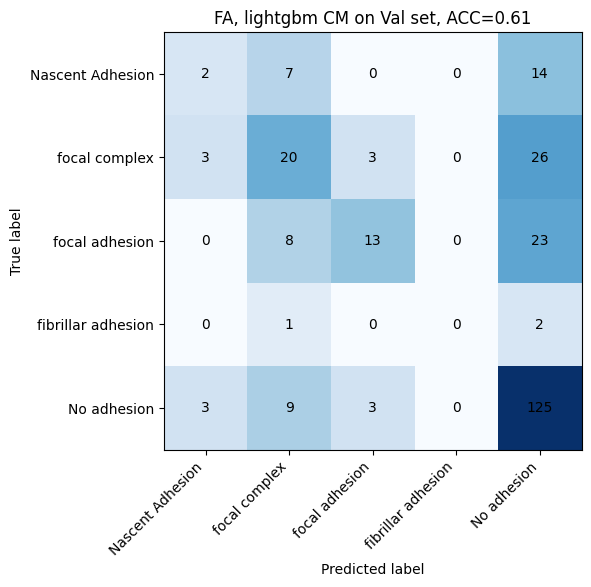

In [45]:
plot_cm(y_val, lightgbm_val_pred,classification_label_order[:-1], "FA, lightgbm" )

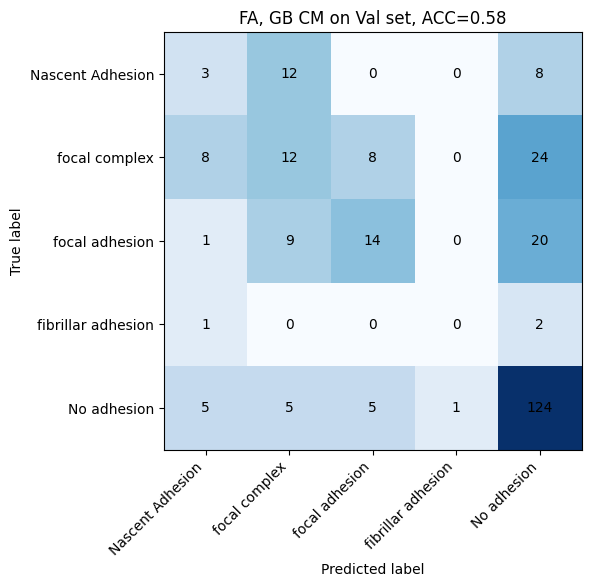

In [46]:
plot_cm(y_val, gb_y_pred,classification_label_order[:-1], "FA, GB" )

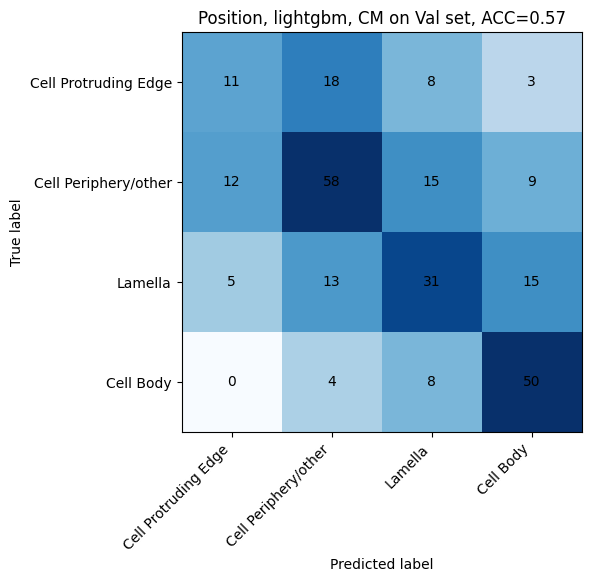

In [79]:
plot_cm(y_val_Position, lightgbm_val_pred_Position, position_label_order[:-1], "Position, lightgbm," )


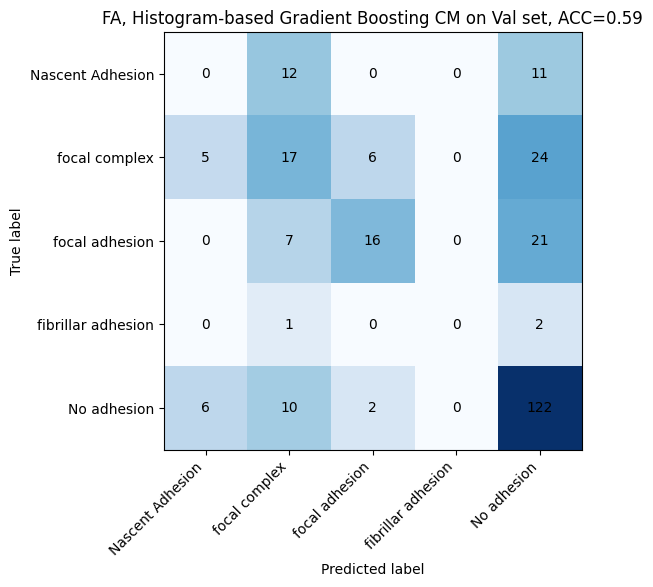

In [47]:
plot_cm(y_val, hgb_y_pred,classification_label_order[:-1], "FA, Histogram-based Gradient Boosting" )


In [51]:
import shutil

In [52]:
def copy_with_prefix(image_folder: str, out_folder: str, prefix_str: str):
    os.makedirs(out_folder, exist_ok=True)

    exts = (".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp")
    for name in os.listdir(image_folder):
        if not name.lower().endswith(exts):
            continue

        src = os.path.join(image_folder, name)

        # avoid double-prefixing
        dst_name = name if name.startswith(prefix_str) else prefix_str+f"{name}"
        dst = os.path.join(out_folder, dst_name)

        shutil.copy2(src, dst)

In [80]:
import numpy as np
import pandas as pd

def predict_all_samples(patch_label_df: pd.DataFrame, lat_features, clf,pred_col_name):
    """
    patch_label_df: dataframe containing feature columns
    lat_features: list of feature column names to use
    clf: trained classifier with predict() and (optionally) predict_proba()
    """
    # 1) Build feature matrix
    X = patch_label_df[lat_features].copy()

    # Optional: ensure numeric (helpful if some cols are object dtype)
    X = X.apply(pd.to_numeric, errors="coerce")

    # 2) Predict labels
    y_pred = clf.predict(X)

    out = patch_label_df.copy()
    out[pred_col_name] = y_pred

    # 3) Predict probabilities if available (nice for multiclass too)
    if hasattr(clf, "predict_proba"):
        proba = clf.predict_proba(X)  # shape: (N, C)
        # store max prob (optional, can remove if you truly want no confidence)
        out["pred_max_proba"] = np.max(proba, axis=1)

        # store per-class probabilities
        n_classes = proba.shape[1]
        for c in range(n_classes):
            out[f"proba_class{c}"] = proba[:, c]

    return out

# Usage:
# pred_df = predict_all_samples(patch_label_df, lat_features, clf)
# pred_df.to_csv("patch_label_df_with_predictions.csv", index=False)

In [81]:
all_pred_df = predict_all_samples(patch_label_df, feature_cols, lightgbm_clf, 'FA_pred')

/home/ldin/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(
/home/ldin/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but HistGradientBoostingClassifier was fitted without feature names
  warnings.warn(


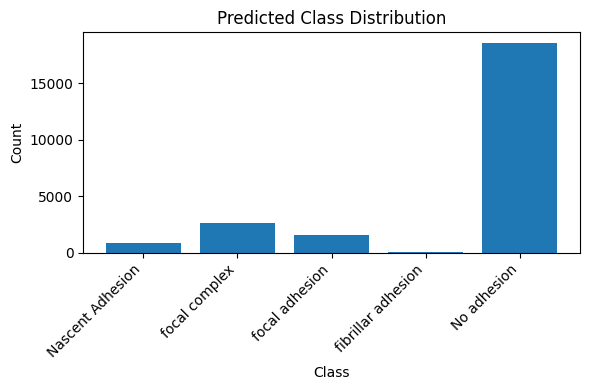

In [61]:

class_names = classification_label_order[:-1]
n_classes = len(class_names)

plt.figure(figsize=(6, 4))

plt.hist(
    all_pred_df['pred'],
    bins=np.arange(n_classes + 1) - 0.5,
    rwidth=0.8
)

plt.xticks(
    np.arange(n_classes),
    class_names,
    rotation=45,
    ha="right"
)

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Predicted Class Distribution")

plt.tight_layout()
plt.show()


In [ ]:
all_pred_df.pred

,Unnamed: 0.1,Unnamed: 0,ctrl_y_str,crop_img_filename,group_labels,UMAP_d0,UMAP_d1,DBSCAN_labels,kmeans_labels,vinculin_intensity,...,lat_d7,group,unique_ID,pred,pred_max_proba,proba_class0,proba_class1,proba_class2,proba_class3,proba_class4
0,0,0,ctrl,f0000x0080y0816ps32.tif,0,6.533898,2.949632,0,0,3470.368164,...,2.258103,control,control-f0000x0080y0816ps32.tif,4,0.949462,0.000012,0.005115,0.045410,1.156303e-06,0.949462
1,1,1,ctrl,f0000x0112y0784ps32.tif,0,0.613508,-1.430238,0,0,2753.338867,...,-2.793007,control,control-f0000x0112y0784ps32.tif,4,0.981634,0.016879,0.000449,0.000859,1.795159e-04,0.981634
2,2,2,ctrl,f0000x0144y0784ps32.tif,0,4.134788,1.867131,0,0,4177.766602,...,-7.896038,control,control-f0000x0144y0784ps32.tif,1,0.602289,0.007103,0.602289,0.206117,2.350334e-03,0.182140
3,3,3,ctrl,f0000x0176y0784ps32.tif,0,6.328398,2.741769,0,0,3782.319336,...,0.339599,control,control-f0000x0176y0784ps32.tif,2,0.443944,0.237581,0.138110,0.443944,5.945552e-05,0.180306
4,4,4,ctrl,f0000x0240y0752ps32.tif,0,5.109221,1.633341,0,0,3487.683594,...,-9.985755,control,control-f0000x0240y0752ps32.tif,2,0.785304,0.081058,0.118692,0.785304,1.669346e-05,0.014930
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23651,23651,23651,y,f0040x0912y0624ps32.tif,1,6.696744,0.453905,0,0,4753.446289,...,-2.702754,ycomp,ycomp-f0040x0912y0624ps32.tif,4,0.972566,0.024440,0.002189,0.000805,3.269127e-07,0.972566
23652,23652,23652,y,f0040x0912y0656ps32.tif,1,5.160360,1.301750,0,0,8459.265625,...,-3.006688,ycomp,ycomp-f0040x0912y0656ps32.tif,2,0.363183,0.347087,0.193671,0.363183,2.267635e-06,0.096057
23653,23653,23653,y,f0040x0912y0688ps32.tif,1,3.375209,-0.521952,0,0,7675.988281,...,-0.333692,ycomp,ycomp-f0040x0912y0688ps32.tif,4,0.961097,0.000164,0.021953,0.016786,5.594650e-07,0.961097
23654,23654,23654,y,f0040x0912y0720ps32.tif,1,5.753994,-0.231215,0,0,5432.383789,...,-6.561848,ycomp,ycomp-f0040x0912y0720ps32.tif,1,0.493765,0.134216,0.493765,0.009837,8.883638e-07,0.362181


In [53]:
control_folder = "/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_gridonly_wholecell_pslocation00/tiff_patches32_40p_20250919_0948"
ycomp_folder = "/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/y_ch1_major/y_ch1_patches_gridonly_wholecell_pslocation00/tiff_patches32_40p_20250919_1005"


In [55]:
copy_with_prefix(ycomp_folder, "/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/pax_patch_cy", "ycomp-")

In [56]:
copy_with_prefix(control_folder, "/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/pax_patch_cy", "control-")

In [ ]:
new_image_folder = "/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/pax_patch_cy"

In [ ]:
new_image_folder = "/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/pax_patch_cy"


In [ ]:
def sort_predictions(
    model,
    transform,
    train_indices,
    val_indices,
    image_folder,
    df,
    device,
    timestamp,
):
    """
    Multiclass version:
    - Creates folders by confusion-pair category: gt{g}_pred{p}
    - No confidence scores / no msp/entropy grouping
    - Test images (not in CSV) are saved under: test/pred{p}
    """

    # Identify "test" images = those present in folder but not listed in CSV
    csv_images = set(df["image"].tolist())
    all_images = {
        f for f in os.listdir(image_folder)
        if f.lower().endswith((".png", ".jpg", ".jpeg", ".tif", ".tiff", ".bmp"))
    }
    test_images = sorted(all_images - csv_images)

    base = os.path.join(image_folder, f"predictions_{timestamp}")
    os.makedirs(base, exist_ok=True)

    model.eval()

    def run_inference(img_path):
        image = Image.open(img_path).convert("RGB")
        image_t = transform(image).unsqueeze(0).to(device)
        with torch.no_grad():
            logits = model(image_t)
            probs = torch.softmax(logits, dim=1)
        pred = probs.argmax(1).item()
        n_classes = probs.shape[1]
        return pred, n_classes

    # Determine number of classes once (from first available image)
    probe_img = None
    if len(train_indices) > 0:
        probe_img = os.path.join(image_folder, df.loc[train_indices[0], "image"])
    elif len(val_indices) > 0:
        probe_img = os.path.join(image_folder, df.loc[val_indices[0], "image"])
    elif len(test_images) > 0:
        probe_img = os.path.join(image_folder, test_images[0])

    if probe_img is None:
        raise ValueError("No images found to infer number of classes.")

    _, n_classes = run_inference(probe_img)

    # Create directories for all gt/pred pairs for train/val
    for split in ["train", "val"]:
        for g in range(n_classes):
            for p in range(n_classes):
                os.makedirs(os.path.join(base, split, f"gt{g}_pred{p}"), exist_ok=True)

    # Create directories for test by predicted class
    for p in range(n_classes):
        os.makedirs(os.path.join(base, "test", f"pred{p}"), exist_ok=True)

    records = []

    for split_name, indices in {"train": train_indices, "val": val_indices}.items():
        print(f"[INFO] Processing {split_name}...")
        for idx in indices:
            img_name = df.loc[idx, "image"]
            gt_label = int(df.loc[idx, "label"])
            img_path = os.path.join(image_folder, img_name)

            pred, _ = run_inference(img_path)

            cat = f"gt{gt_label}_pred{pred}"
            out_name = img_name  # keep original name; change if you want prefixes

            shutil.copy(img_path, os.path.join(base, split_name, cat, out_name))

            records.append({
                "image": img_name,
                "split": split_name,
                "gt_label": gt_label,
                "pred": pred,
                "category": cat,
            })

    print("[INFO] Processing test...")
    for img_name in test_images:
        img_path = os.path.join(image_folder, img_name)
        pred, _ = run_inference(img_path)

        cat = f"pred{pred}"
        out_name = img_name
        shutil.copy(img_path, os.path.join(base, "test", cat, out_name))

        records.append({
            "image": img_name,
            "split": "test",
            "gt_label": None,
            "pred": pred,
            "category": cat,
        })

    out_csv = os.path.join(base, "predictions_multiclass.csv")
    pd.DataFrame(records).to_csv(out_csv, index=False)
    print(f"\n[DONE] Predictions saved to: {base}")
    print(f"[DONE] CSV written to: {out_csv}")